In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import h5py, os, tqdm
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm import camels

jax.devices("gpu")

[cuda(id=0)]

In [4]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## Loading the snapshots

In [5]:
# i_snapshots=range(1, 33+4, 4)
i_snapshots=[-2,-1]
# i_snapshots = None

In [7]:
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0"

sim_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    # force_h5=True,
)

Loaded /cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/parts=64,mesh=64,i=[-2, -1].h5


In [10]:
scales, particle_features, field_features = camels.preprocess_snapshots(sim_dict)

In [13]:
field_features.keys()

dict_keys(['rho_gas', 'fscalar_gas', 'vel_disp_gas', 'vel_div_gas', 'tidal_eigval_gas_0', 'tidal_eigval_gas_1', 'tidal_eigval_gas_2', 'P_gas', 'U_gas', 'T_gas'])

In [69]:
def normalized_paint(positions, weights):
    N_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_N = cic_read(N_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_N)

def plot_field(field, ax, vlims=None):
    # log_sum = jnp.log10(field.sum(axis=0))
    log_sum = jnp.arcsinh(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims

    ax.set_xticks([])
    ax.set_yticks([])
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum


# velocity dispersion

In [24]:
i = -1
gas_pos = sim_dict["gas_poss"][i]
gas_vel = sim_dict["gas_vels"][i]

# particle count
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

In [25]:
# for vector fields
vcic_paint = jax.vmap(cic_paint, in_axes=(None, None, -1), out_axes=-1)
vcic_read = jax.vmap(cic_read, in_axes=(-1, None), out_axes=-1)

# mean velocity per voxel
vel_mean_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])
# per particle
gas_vel_mean = vcic_read(vel_mean_gas, gas_pos)
gas_vel_disp = jnp.sum((gas_vel_mean - gas_vel)**2, axis=-1)

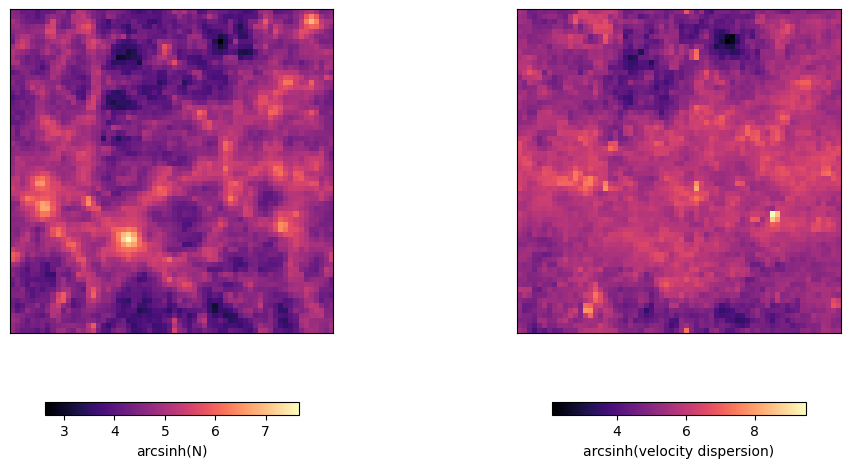

In [26]:
vel_disp_gas = normalized_paint(gas_pos, gas_vel_disp)
# vel_disp_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=gas_vel_disp/gas_N)

fig, ax = plt.subplots(figsize=(2*6, 6), ncols=2)

im, _, _ = plot_field(N_gas, ax[0])
fig.colorbar(im, ax=ax[0], label="arcsinh(N)", orientation="horizontal", shrink=0.6, aspect=20)

im, _, _ = plot_field(vel_disp_gas, ax[1])
fig.colorbar(im, ax=ax[1], label="arcsinh(velocity dispersion)", orientation="horizontal", shrink=0.6, aspect=20)

# velocity divergence

In [27]:
kvec = fftk(mesh_shape)

# particle -> field (which is again the mean)
vel_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])
# vel_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel)
vel_gas_k = jnp.fft.rfftn(vel_gas, axes=(0,1,2))

# derivative in fourier space
gas_vel_div = [cic_read(jnp.fft.irfftn(gradient_kernel(kvec, i) * vel_gas_k[...,i]), gas_pos) for i in range(len(kvec))]
gas_vel_div = jnp.stack(gas_vel_div, axis=-1)
gas_vel_div = jnp.sum(gas_vel_div, axis=-1)

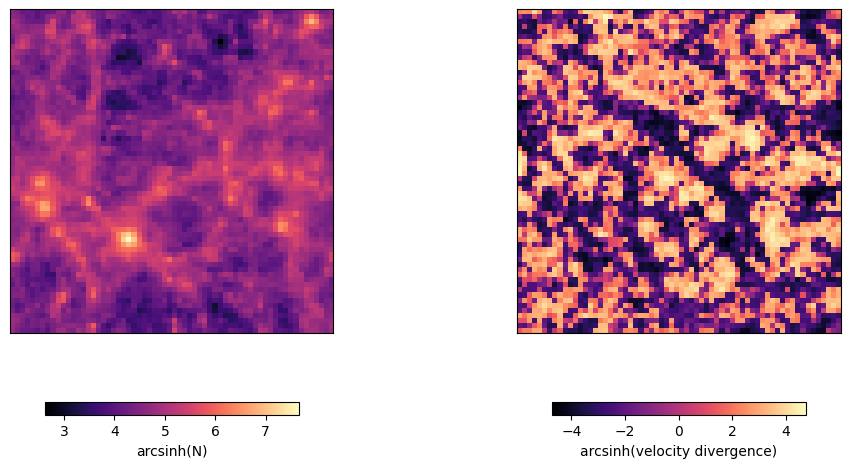

In [28]:
vel_div_gas = normalized_paint(gas_pos, gas_vel_div)
# vel_div_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=gas_vel_div/gas_N)

fig, ax = plt.subplots(figsize=(2*6, 6), ncols=2)

im, _, _ = plot_field(N_gas, ax[0])
fig.colorbar(im, ax=ax[0], label="arcsinh(N)", orientation="horizontal", shrink=0.6, aspect=20)

im, _, _ = plot_field(vel_div_gas, ax[1])
fig.colorbar(im, ax=ax[1], label="arcsinh(velocity divergence)", orientation="horizontal", shrink=0.6, aspect=20)

# tidal field

In [43]:
rho = cic_paint(jnp.zeros(shape=mesh_shape), gas_pos)
delta_k = jnp.fft.fftn(rho)

kvec = fftk(mesh_shape, symmetric=False)
kk = jnp.sqrt(sum((ki / jnp.pi)**2 for ki in kvec))
kk = jnp.where(kk == 0, 1., kk)

# Compute the tidal field at the position of each particle
T_xx = cic_read(jnp.fft.ifftn(-(kvec[0]**2) * delta_k / kk).real, gas_pos)
T_yy = cic_read(jnp.fft.ifftn(-(kvec[1]**2) * delta_k / kk).real, gas_pos)
T_zz = cic_read(jnp.fft.ifftn(-(kvec[2]**2) * delta_k / kk).real, gas_pos)
T_xy = cic_read(jnp.fft.ifftn(-(kvec[0] * kvec[1]) * delta_k / kk).real, gas_pos)
T_xz = cic_read(jnp.fft.ifftn(-(kvec[0] * kvec[2]) * delta_k / kk).real, gas_pos)
T_yz = cic_read(jnp.fft.ifftn(-(kvec[1] * kvec[2]) * delta_k / kk).real, gas_pos)

# shape (N,3,3)
T = jnp.stack(
    [jnp.stack([T_xx, T_xy, T_xz], -1), jnp.stack([T_xy, T_yy, T_yz], -1), jnp.stack([T_xz, T_yz, T_zz], -1)], -2
)

# symmetric, so eigh is fine
eigval, eigvec = jnp.linalg.eigh(T)  

In [87]:
delta_k.shape

(64, 64, 64)

In [84]:
kk.shape

(64, 64, 64)

In [47]:
eigval.shape

(262144, 3)

In [60]:
eigvec.shape

(262144, 3, 3)

In [61]:
T.shape

(262144, 3, 3)

In [55]:
ax.shape

(3, 2)

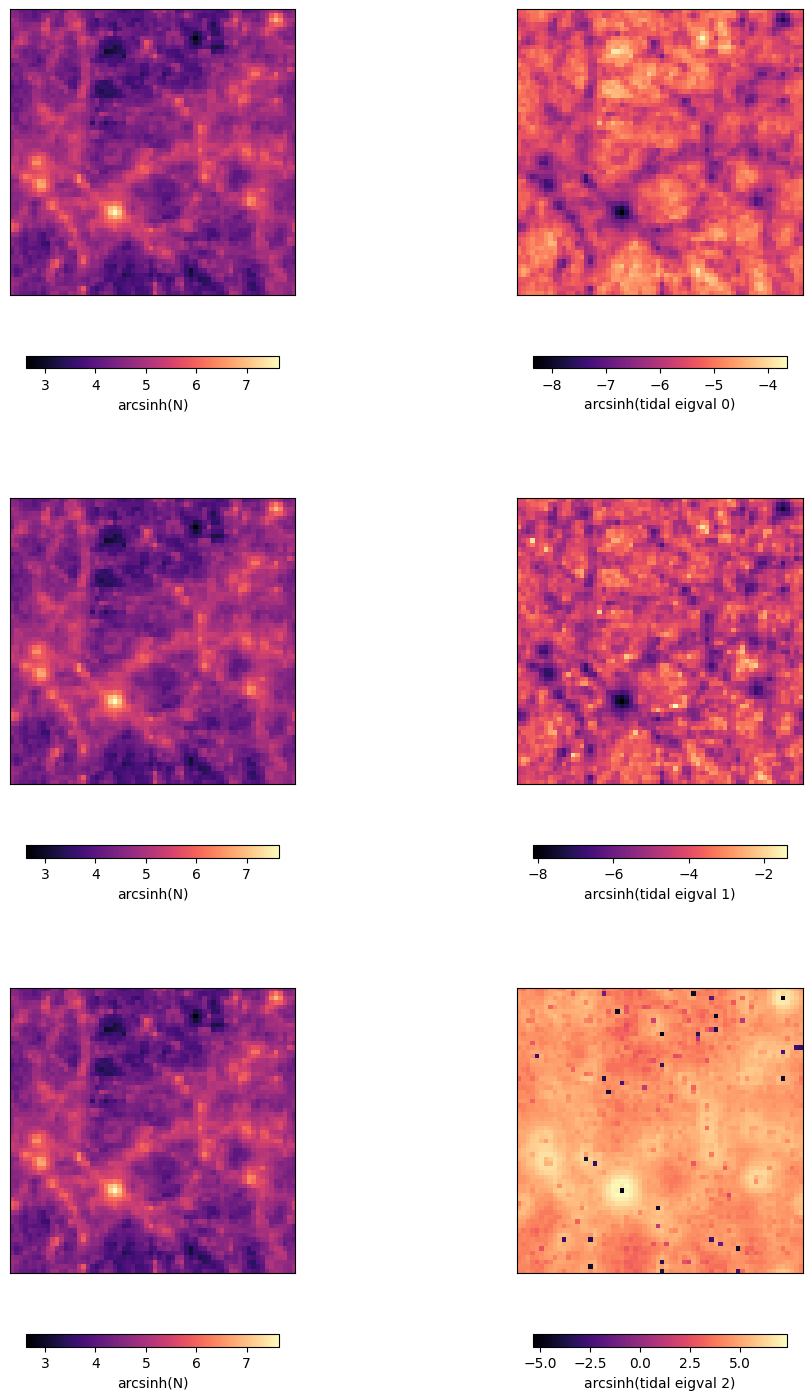

In [59]:
fig, ax = plt.subplots(figsize=(2*6, 3*6), ncols=2, nrows=eigval.shape[-1])

for i in range(eigval.shape[-1]):
    tidal_eigval_gas = normalized_paint(gas_pos, eigval[:,i])

    im, _, _ = plot_field(N_gas, ax[i,0])
    fig.colorbar(im, ax=ax[i,0], label="arcsinh(N)", orientation="horizontal", shrink=0.6, aspect=20)
    
    im, _, _ = plot_field(tidal_eigval_gas, ax[i,1])
    fig.colorbar(im, ax=ax[i,1], label=f"arcsinh(tidal eigval {i})", orientation="horizontal", shrink=0.6, aspect=20)


In [45]:
eigval.shape

(262144, 3)

In [46]:
eigvec.shape

(262144, 3, 3)

In [42]:
T.shape

(262144, 3, 3)

In [30]:
kvec = fftk(mesh_shape, symmetric=False)
kk = jnp.sqrt(sum((ki / jnp.pi)**2 for ki in kvec))
kk = jnp.where(kk == 0, 1., kk)



In [ ]:
# Compute the tidal field at the position of each particle
T_xx = cic_read(jnp.fft.ifftn(-(kvec[0]**2) * delta_k / kk).real, pos)
T_yy = cic_read(jnp.fft.ifftn(-(kvec[1]**2) * delta_k / kk).real, pos)
T_zz = cic_read(jnp.fft.ifftn(-(kvec[2]**2) * delta_k / kk).real, pos)
T_xy = cic_read(jnp.fft.ifftn(-(kvec[0] * kvec[1]) * delta_k / kk).real, pos)
T_xz = cic_read(jnp.fft.ifftn(-(kvec[0] * kvec[2]) * delta_k / kk).real, pos)
T_yz = cic_read(jnp.fft.ifftn(-(kvec[1] * kvec[2]) * delta_k / kk).real, pos)

# rotationally invariant features per particle
delta = cic_read(rho, pos) - 0.99

T = jnp.stack([                      # shape (N,3,3)
        jnp.stack([T_xx, T_xy, T_xz], -1),
        jnp.stack([T_xy, T_yy, T_yz], -1),
        jnp.stack([T_xz, T_yz, T_zz], -1)], -2)

eigval, eigvec = jnp.linalg.eigh(T)  # symmetric, so eigh is fine

# comments

In [ ]:
# normalizing on the field-level
vel_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel)
vel_mean_gas_1 = vel_gas/N_gas[...,jnp.newaxis]

# normalizing on the particle-level
vel_mean_gas_2 = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])

print(jnp.allclose(vel_mean_gas_1, vel_mean_gas_2))

# is identical except for division by zero

# trash

In [ ]:
N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos)
gas_N = cic_read(N_gas, gas_pos)

vel_gas = jax.vmap(
    cic_paint, 
    in_axes=(None, None, -1),
    out_axes=-1,
)(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])

vel_gas = jnp.sum(vel_gas, axis=-1)

# mean_vel_gas = vel_gas/N_gas
# gas_mean_vel = 

In [ ]:
vel_gas.shape

In [ ]:
vel_gas.max()

In [ ]:
vel_gas.min()

In [ ]:
jnp.arcsinh(vel_gas).min(), jnp.arcsinh(vel_gas).max()

In [ ]:
fig, ax = plt.subplots(figsize=(2*6, 6), ncols=2)

im, _, _ = plot_field(N_gas, ax[0])
fig.colorbar(im, ax=ax[0], label="arcsinh(N)", orientation="horizontal", shrink=0.6, aspect=20)

im, _, _ = plot_field(vel_gas, ax[1])
fig.colorbar(im, ax=ax[1], label="arcsinh(velocity)", orientation="horizontal", shrink=0.6, aspect=20)